# 0. Abstract & Introduction

In [133]:
# ── Bibliotecas Estándar y Configuración ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_recall_curve

# Configuración Q1 Standard
warnings.filterwarnings('ignore')
sns.set_theme(style='white', context='paper')
plt.rcParams.update({'font.size': 12})
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [134]:
# ── Funciones de Utilidad (Phase 0) ────────────────────────────────────────
def get_vae_diagnostics(model, data_tensor):
    """Encapsula la inferencia del VAE para generar métricas de diagnóstico."""
    model.eval()
    with torch.no_grad():
        # Asegurar forma [N, features]
        flat_input = data_tensor.view(data_tensor.size(0), -1)
        x_recon, mu, logvar = model(flat_input)
        # MSE por ventana
        mse = torch.mean((flat_input - x_recon)**2, dim=1)
    return mse.cpu().numpy(), mu.cpu().numpy()

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

# Section 1: Data Engineering & EDA

Se realiza la ingesa y preparación de los datos NASA C-MAPSS. Se aplica un filtrado de sensores constantes y se analiza la correlación de Spearman para validar la relevancia física de las señales antes de la normalización adaptativa y la generación de ventanas temporales.

In [135]:
COLUMN_NAMES = (
    ['unit_number', 'time_in_cycles'] +
    [f'setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)
DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']

def load_cmapss(dataset_id: str, base_path: str = 'CMAPSSData') -> dict:
    train  = pd.read_csv(f'{base_path}/train_{dataset_id}.txt', sep='\\s+', header=None, names=COLUMN_NAMES)
    test   = pd.read_csv(f'{base_path}/test_{dataset_id}.txt',  sep='\\s+', header=None, names=COLUMN_NAMES)
    rul_gt = pd.read_csv(f'{base_path}/RUL_{dataset_id}.txt',   sep='\\s+', header=None, names=['RUL_true'])
    return {'train': train, 'test': test, 'rul_gt': rul_gt}

data = {ds: load_cmapss(ds) for ds in DATASETS}

# VISUALIZACIÓN DE LOS DATOS CRUDOS
print(f'\nEjemplo de los primeros registros del dataset FD001 (Train):')
print(f'Total de filas: {len(data["FD001"]["train"])} | Total de columnas: {len(data["FD001"]["train"].columns)}\n')

# Renombramos las columnas temporalmente para la tabla (las constantes marcadas con ❌)
rename_dict = {
    'unit_number': 'Motor', 'time_in_cycles': 'Ciclo',
    'sensor_1': '❌ T2 (Const)', 'sensor_2': '✅ T24', 'sensor_3': '✅ T30', 'sensor_4': '✅ T50', 
    'sensor_5': '❌ P2 (Const)', 'sensor_6': '❌ P15 (Const)', 'sensor_7': '✅ P30', 'sensor_8': '✅ Nf', 
    'sensor_9': '✅ Nc', 'sensor_10': '❌ epr (Const)', 'sensor_11': '✅ Ps30', 'sensor_12': '✅ phi', 
    'sensor_13': '✅ NRf', 'sensor_14': '✅ NRc', 'sensor_15': '✅ BPR', 'sensor_16': '❌ farB (Const)', 
    'sensor_17': '✅ htBleed', 'sensor_18': '❌ Nf_dmd (Const)', 'sensor_19': '❌ PCNfR_dmd (Const)', 
    'sensor_20': '✅ W31', 'sensor_21': '✅ W32'
}
df_show = data['FD001']['train'].head().rename(columns=rename_dict)

# Función para sombrear las columnas constantes de rojo suave para que destaquen visualmente
def highlight_const(col):
    if '❌' in col.name:
        return ['background-color: #FF0000'] * len(col)
    return [''] * len(col)

display(df_show.style.apply(highlight_const, axis=0))

print('\nDistribución de motores por dataset:')
for ds in DATASETS:
    n_units = data[ds]['train']['unit_number'].nunique()
    n_rows = len(data[ds]['train'])
    print(f' - {ds}: {n_units} motores ({n_rows} ciclos totales)')



Ejemplo de los primeros registros del dataset FD001 (Train):
Total de filas: 20631 | Total de columnas: 26



,Motor,Ciclo,setting_1,setting_2,setting_3,❌ T2 (Const),✅ T24,✅ T30,✅ T50,❌ P2 (Const),❌ P15 (Const),✅ P30,✅ Nf,✅ Nc,❌ epr (Const),✅ Ps30,✅ phi,✅ NRf,✅ NRc,✅ BPR,❌ farB (Const),✅ htBleed,❌ Nf_dmd (Const),❌ PCNfR_dmd (Const),✅ W31,✅ W32
0,1,1,-0.000700,-0.000400,100.000000,518.670000,641.820000,1589.700000,1400.600000,14.620000,21.610000,554.360000,2388.060000,9046.190000,1.300000,47.470000,521.660000,2388.020000,8138.620000,8.419500,0.030000,392,2388,100.000000,39.060000,23.419000
1,1,2,0.001900,-0.000300,100.000000,518.670000,642.150000,1591.820000,1403.140000,14.620000,21.610000,553.750000,2388.040000,9044.070000,1.300000,47.490000,522.280000,2388.070000,8131.490000,8.431800,0.030000,392,2388,100.000000,39.000000,23.423600
2,1,3,-0.004300,0.000300,100.000000,518.670000,642.350000,1587.990000,1404.200000,14.620000,21.610000,554.260000,2388.080000,9052.940000,1.300000,47.270000,522.420000,2388.030000,8133.230000,8.417800,0.030000,390,2388,100.000000,38.950000,23.344200
3,1,4,0.000700,0.000000,100.000000,518.670000,642.350000,1582.790000,1401.870000,14.620000,21.610000,554.450000,2388.110000,9049.480000,1.300000,47.130000,522.860000,2388.080000,8133.830000,8.368200,0.030000,392,2388,100.000000,38.880000,23.373900
4,1,5,-0.001900,-0.000200,100.000000,518.670000,642.370000,1582.850000,1406.220000,14.620000,21.610000,554.000000,2388.060000,9055.150000,1.300000,47.280000,522.190000,2388.040000,8133.800000,8.429400,0.030000,393,2388,100.000000,38.900000,23.404400



Distribución de motores por dataset:
 - FD001: 100 motores (20631 ciclos totales)
 - FD002: 260 motores (53759 ciclos totales)
 - FD003: 100 motores (24720 ciclos totales)
 - FD004: 249 motores (61249 ciclos totales)


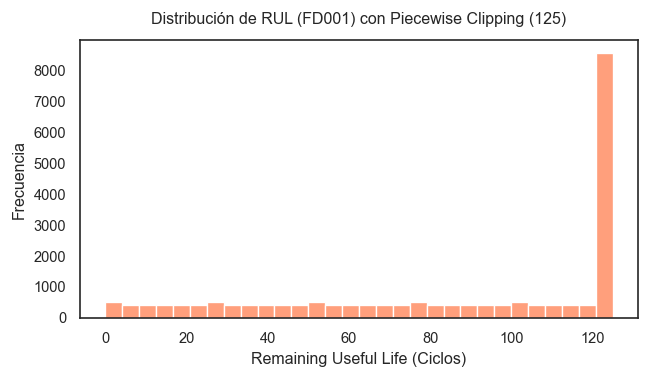

In [136]:
RUL_CLIP = 125

def add_rul_label(df, clip=RUL_CLIP):
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max().rename('max_cycles')
    df = df.join(max_cycles, on='unit_number')
    df['RUL'] = (df['max_cycles'] - df['time_in_cycles']).clip(upper=clip)
    df.drop(columns=['max_cycles'], inplace=True)
    return df

for ds in DATASETS:
    data[ds]['train'] = add_rul_label(data[ds]['train'])

# VISUALIZACIÓN
plt.figure(figsize=(6, 3))
sns.histplot(data['FD001']['train']['RUL'], bins=30, kde=False, color='coral')
plt.title(f'Distribución de RUL (FD001) con Piecewise Clipping ({RUL_CLIP})', pad=10)
plt.xlabel('Remaining Useful Life (Ciclos)')
plt.ylabel('Frecuencia')
plt.show()


In [137]:
FEATURE_COLS = [f'setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
std_per_dataset = pd.DataFrame({ds: data[ds]['train'][FEATURE_COLS].std() for ds in DATASETS})
constant_per_ds = {ds: std_per_dataset[ds][std_per_dataset[ds] == 0].index.tolist() for ds in DATASETS}

ID_COLS = ['unit_number', 'time_in_cycles']
for ds in DATASETS:
    useful = [c for c in FEATURE_COLS if c not in constant_per_ds[ds]]
    data[ds]['useful_cols']  = useful
    data[ds]['train_clean']  = data[ds]['train'][ID_COLS + useful + ['RUL']].copy()
    data[ds]['test_clean']   = data[ds]['test'][ID_COLS + useful].copy()

# VISUALIZACIÓN (PRINT DE DROPS)
print('✅ Features irrelevantes (varianza 0) eliminadas:')
for ds in DATASETS:
    dropped = constant_per_ds[ds]
    print(f'  {ds}: {len(dropped)} eliminadas -> {dropped}')


✅ Features irrelevantes (varianza 0) eliminadas:
  FD001: 5 eliminadas -> ['setting_3', 'sensor_1', 'sensor_10', 'sensor_18', 'sensor_19']
  FD002: 0 eliminadas -> []
  FD003: 4 eliminadas -> ['setting_3', 'sensor_1', 'sensor_18', 'sensor_19']
  FD004: 0 eliminadas -> []


In [ ]:
# ── Normalización Min-Max ajustada sobre train, aplicada a train y test ───────
scalers = {}

for ds in DATASETS:
    feats   = data[ds]['useful_cols']
    scaler  = MinMaxScaler(feature_range=(0, 1))

    # Ajustar SOLO sobre train (evita data leakage)
    train_arr = scaler.fit_transform(data[ds]['train_clean'][feats])
    test_arr  = scaler.transform(data[ds]['test_clean'][feats])

    # Reemplazar columnas en los DataFrames limpios
    data[ds]['train_clean'][feats] = train_arr
    data[ds]['test_clean'][feats]  = test_arr

    scalers[ds] = scaler   # guardar para inferencia futura

# ── Verificación: rango de valores tras normalización ─────────────────────────
print(f'📐 Rango de features en train tras normalización')
for ds in DATASETS:
    feats   = data[ds]['useful_cols']
    min_val = data[ds]['train_clean'][feats].min().min()
    max_val = data[ds]['train_clean'][feats].max().max()
    print(f'  {ds}:  min = {min_val:.4f}   max = {max_val:.4f}')

print('\n✅ Hito 1.2 completado — datos normalizados en [0, 1].')

📐 Rango de features en train tras normalización (esperado: 0.0 – 1.0)

  FD001:  min = 0.0000   max = 1.0000
  FD002:  min = 0.0000   max = 1.0000
  FD003:  min = 0.0000   max = 1.0000
  FD004:  min = 0.0000   max = 1.0000

✅ Hito 1.2 completado — datos normalizados en [0, 1].


In [139]:
WINDOW_SIZE = 30

def make_windows_train(df: pd.DataFrame, features: list, window: int = WINDOW_SIZE):
    """Tensores 3D de entrenamiento: X[N, window, F], y[N], IDs[N], Cycles[N]."""
    X_list, y_list, id_list, cyc_list = [], [], [], []
    for _, unit_df in df.groupby('unit_number'):
        unit_x = unit_df[features].values
        unit_y = unit_df['RUL'].values
        unit_id = unit_df['unit_number'].values
        unit_cyc = unit_df['time_in_cycles'].values
        T = len(unit_df)
        if T < window:
            continue
        for i in range(window, T + 1):
            X_list.append(unit_x[i - window: i])
            y_list.append(unit_y[i - 1])
            id_list.append(unit_id[i - 1])
            cyc_list.append(unit_cyc[i - 1])
    return (
        np.array(X_list, dtype=np.float32), 
        np.array(y_list, dtype=np.float32), 
        np.array(id_list), 
        np.array(cyc_list)
    )

def make_windows_test(df: pd.DataFrame, features: list, window: int = WINDOW_SIZE):
    """Tensores 3D de test: última ventana de cada motor + ID."""
    X_list, id_list = [], []
    for _, unit_df in df.groupby('unit_number'):
        unit_x = unit_df[features].values
        T = len(unit_df)
        if T >= window:
            X_list.append(unit_x[-window:])
        else:
            pad = np.zeros((window - T, len(features)), dtype=np.float32)
            X_list.append(np.vstack([pad, unit_x]))
        id_list.append(unit_df['unit_number'].values[-1])
    return np.array(X_list, dtype=np.float32), np.array(id_list)

print(f'✅ Funciones de ventana actualizadas (con tracking de ID). Window size = {WINDOW_SIZE} ciclos.')

✅ Funciones de ventana actualizadas (con tracking de ID). Window size = 30 ciclos.


In [140]:
tensors = {}

for ds in DATASETS:
    feats = data[ds]['useful_cols']
    X_tr, y_tr, ids_tr, cyc_tr = make_windows_train(data[ds]['train_clean'], feats)
    X_te, ids_te             = make_windows_test(data[ds]['test_clean'],  feats)
    tensors[ds] = {
        'X_train': X_tr, 'y_train': y_tr, 'ids_train': ids_tr, 'cycles_train': cyc_tr,
        'X_test': X_te, 'ids_test': ids_te
    }

print(f'\n📐 Tensores generados (con IDs y Ciclos) (window = {WINDOW_SIZE}):\n')
print(f'  {"Dataset":<8}  {"X_train":>20}  {"y_train":>12}  {"X_test":>20}')
print('  ' + '-'*64)
for ds in DATASETS:
    xt = tensors[ds]['X_train'].shape
    yt = tensors[ds]['y_train'].shape
    xe = tensors[ds]['X_test'].shape
    print(f'  {ds:<8}  {str(xt):>20}  {str(yt):>12}  {str(xe):>20}')

print('\n  Formato: [muestras, ventana=30, n_features]')


📐 Tensores generados (con IDs y Ciclos) (window = 30):

  Dataset                X_train       y_train                X_test
  ----------------------------------------------------------------
  FD001          (17731, 30, 19)      (17731,)         (100, 30, 19)
  FD002          (46219, 30, 24)      (46219,)         (259, 30, 24)
  FD003          (21820, 30, 20)      (21820,)         (100, 30, 20)
  FD004          (54028, 30, 24)      (54028,)         (248, 30, 24)

  Formato: [muestras, ventana=30, n_features]


# EDA Multi-Dataset Comparativo
Analizamos la consistencia de las señales de degradación a través de los cuatro escenarios de la NASA (FD001-FD004). Este análisis es fundamental para demostrar que los sensores seleccionados mantienen su relevancia estadística incluso ante variaciones operativas y de condiciones de vuelo.

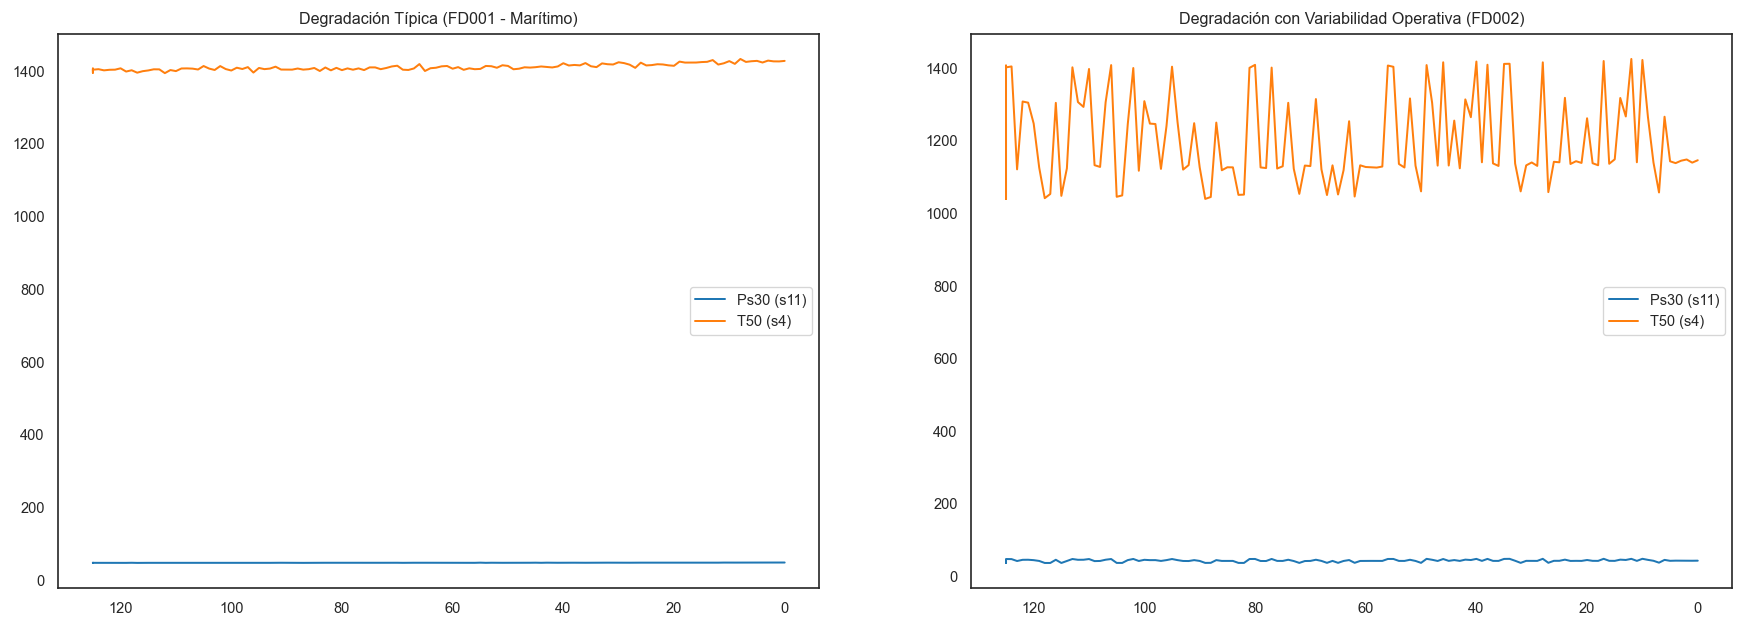

In [141]:
# ── Trayectorias de Degradación en Múltiples Escenarios ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Caso FD001: Condición Simple
engine_id_1 = data['FD001']['train']['unit_number'].unique()[0]
engine_data_1 = data['FD001']['train'][data['FD001']['train']['unit_number'] == engine_id_1]
axes[0].plot(engine_data_1['RUL'], engine_data_1['sensor_11'], label='Ps30 (s11)', color='tab:blue')
axes[0].plot(engine_data_1['RUL'], engine_data_1['sensor_4'], label='T50 (s4)', color='tab:orange')
axes[0].set_title('Degradación Típica (FD001 - Marítimo)')
axes[0].invert_xaxis()
axes[0].legend()

# Caso FD002: Condiciones Múltiples
engine_id_2 = data['FD002']['train']['unit_number'].unique()[5]
engine_data_2 = data['FD002']['train'][data['FD002']['train']['unit_number'] == engine_id_2]
axes[1].plot(engine_data_2['RUL'], engine_data_2['sensor_11'], label='Ps30 (s11)', color='tab:blue')
axes[1].plot(engine_data_2['RUL'], engine_data_2['sensor_4'], label='T50 (s4)', color='tab:orange')
axes[1].set_title('Degradación con Variabilidad Operativa (FD002)')
axes[1].invert_xaxis()
axes[1].legend()

plt.show()

Calculando correlaciones de Spearman para todos los datasets...


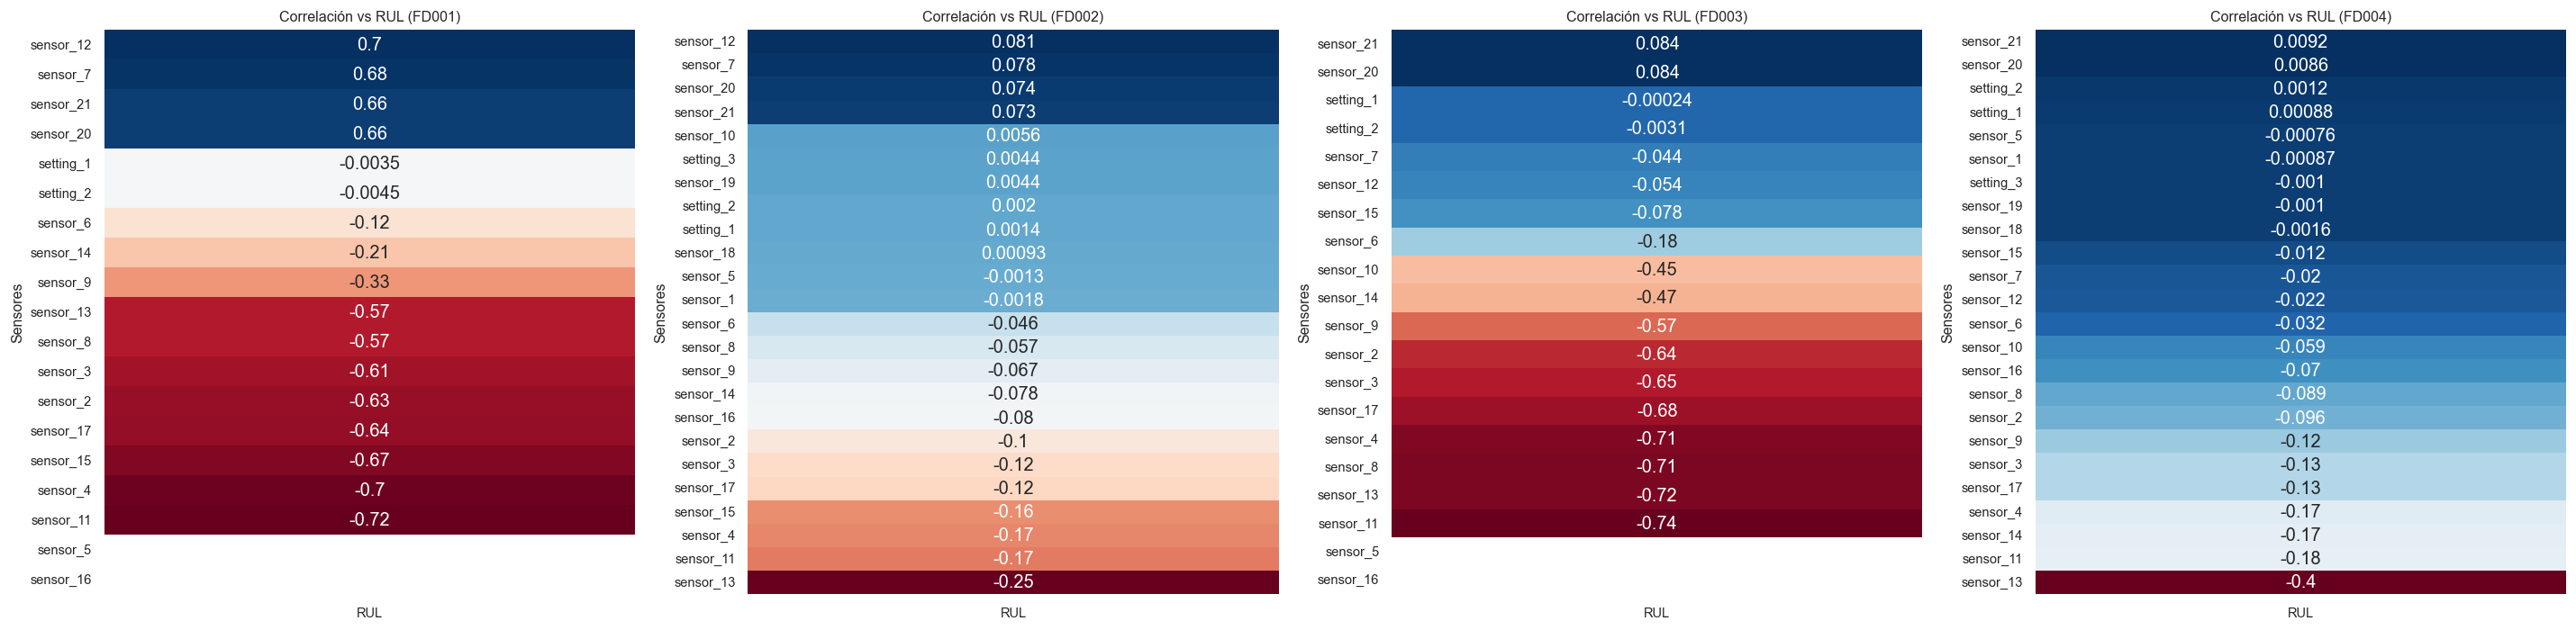

In [142]:
# ── Análisis de Correlación de Spearman Comparativo (All Datasets) ──────────
print('Calculando correlaciones de Spearman para todos los datasets...')
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, ds in enumerate(DATASETS):
    # 1. Calculamos matriz de correlación para el dataset actual
    useful_cols = data[ds]['useful_cols'] + ['RUL']
    corr_matrix = data[ds]['train'][useful_cols].corr(method='spearman')
    
    # 2. Extraemos la correlación con el RUL
    rul_corr = corr_matrix['RUL'].drop('RUL').sort_values(ascending=False)
    
    # 3. Visualización
    sns.heatmap(rul_corr.to_frame(), annot=True, cmap='RdBu', cbar=False, ax=axes[i])
    axes[i].set_title(f'Correlación vs RUL ({ds})')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Sensores')

plt.tight_layout()
plt.show()

# Section 2: Phase 1 — Unsupervised Anomaly Detection (VAE)

Se entrena un **Variational Autoencoder (VAE)** para capturar la distribución de probabilidad de los estados nominales (healthy), permitiendo detectar desviaciones estocásticas en la fase de degradación. El error de reconstrucción actúa como un indicador de salud no supervisado.

In [143]:

# 1. Configuración de dispositivo (GPU si está disponible, sino CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Dispositivo de PyTorch configurado: {device}\n")

class VAE(nn.Module):
    """
    Autoencoder Variacional (VAE) para ventanas de series temporales.
    """
    def __init__(self, input_dim, hidden_dim_1=128, hidden_dim_2=64, latent_dim=10):
        super(VAE, self).__init__()
        
        # ENCODER: Comprime la ventana de entrada 'x' hacia un espacio latente reducido
        self.fc1 = nn.Linear(input_dim, hidden_dim_1)
        self.fc2 = nn.Linear(hidden_dim_1, hidden_dim_2)
        
        # LATENT SPACE: Capas estocásticas (Media y Varianza logarítmica)
        self.fc_mu = nn.Linear(hidden_dim_2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim_2, latent_dim)
        
        # DECODER: Reconstruye la entrada original 'x' desde el vector latente 'z'
        self.fc3 = nn.Linear(latent_dim, hidden_dim_2)
        self.fc4 = nn.Linear(hidden_dim_2, hidden_dim_1)
        self.fc5 = nn.Linear(hidden_dim_1, input_dim)
        
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        return self.fc_mu(h2), self.fc_logvar(h2)
        
    def reparameterize(self, mu, logvar):
        """
        Reparameterization Trick: z = mu + std * epsilon
        Permite que el gradiente fluya hacia atrás a través del muestreo aleatorio.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        h4 = F.relu(self.fc4(h3))
        # Usamos Sigmoid porque nuestros datos están normalizados con Min-Max en el rango [0, 1]
        x_recon = torch.sigmoid(self.fc5(h4))
        return x_recon
        
    def forward(self, x):
        # Aplanamos la ventana 3D a un vector 1D (si hace falta se hace fuera, pero por si acaso)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

def vae_loss_function(x_recon, x, mu, logvar):
    """
    Función de coste del VAE: MSE (Error de Reconstrucción) + KLD (Regularización)
    """
    # 1. Error de Reconstrucción (Mean Squared Error)
    # 'reduction="sum"' asegura que se penaliza el error acumulado de toda la ventana
    recon_loss = F.mse_loss(x_recon, x, reduction='sum')
    
    # 2. KL Divergence (Kullback-Leibler) - Evita que el espacio latente colapse o se descontrole
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_divergence, recon_loss, kl_divergence


# Prueba de instanciación con el dataset FD001: (Ventana=30 x 19 features seleccionadas)
n_features_fd001 = len(data['FD001']['useful_cols'])
input_size_fd001 = WINDOW_SIZE * n_features_fd001

# Instanciamos y movemos al dispositivo
model_vae = VAE(input_dim=input_size_fd001).to(device)
print(f"✅ Arquitectura VAE definida e inicializada con éxito.")
print(f"   - Dimensiones de la capa de entrada (Aplanada): {input_size_fd001} (30 ciclos x {n_features_fd001} sensores)")
print(f"   - Dimensiones del espacio latente: {model_vae.fc_mu.out_features}")


🚀 Dispositivo de PyTorch configurado: cpu

✅ Arquitectura VAE definida e inicializada con éxito.
   - Dimensiones de la capa de entrada (Aplanada): 570 (30 ciclos x 19 sensores)
   - Dimensiones del espacio latente: 10


In [144]:

# 1. Aislar las ventanas sanas (RUL == 125)
X_train_fd001 = tensors['FD001']['X_train']
y_train_fd001 = tensors['FD001']['y_train']
ids_train_fd001 = tensors['FD001']['ids_train']
cycles_train_fd001 = tensors['FD001']['cycles_train']

healthy_mask = (y_train_fd001 == 125)
X_train_healthy = X_train_fd001[healthy_mask]

print(f"\U0001F538 Total de ventanas de entrenamiento FD001: {len(y_train_fd001)}")
print(f"\U0001F538 Ventanas sanas (RUL=125) usadas para entrenar el modelo general (nominales): {len(X_train_healthy)}")

# 2. Crear DataLoader de PyTorch
X_train_tensor = torch.tensor(X_train_healthy, dtype=torch.float32).to(device)
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 3. Bucle de Entrenamiento
def train_vae(model, dataloader, epochs=50, learning_rate=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    history = {'total_loss': [], 'recon_loss': [], 'kl_loss': []}
    
    for epoch in range(epochs):
        train_loss, train_recon, train_kl = 0, 0, 0
        for batch in dataloader:
            x_batch = batch[0]
            batch_size = x_batch.size(0)
            x_batch_flat = x_batch.view(batch_size, -1)
            optimizer.zero_grad()
            x_recon, mu, logvar = model(x_batch_flat)
            loss, recon_loss, kl_loss = vae_loss_function(x_recon, x_batch_flat, mu, logvar)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_recon += recon_loss.item()
            train_kl += kl_loss.item()
        num_batches = len(dataloader)
        history['total_loss'].append(train_loss / num_batches)
        history['recon_loss'].append(train_recon / num_batches)
        history['kl_loss'].append(train_kl / num_batches)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{(epoch+1):02d}/{epochs}] | Loss Total: {train_loss/num_batches:.2f} | Error Reconstrucción (MSE): {train_recon/num_batches:.2f} | KLD: {train_kl/num_batches:.2f}")
    return history

EPOCHS = 50
history = train_vae(model_vae, train_loader, epochs=EPOCHS)
print("\u2705 Entrenamiento completado.")

🔸 Total de ventanas de entrenamiento FD001: 17731
🔸 Ventanas sanas (RUL=125) usadas para entrenar el modelo general (nominales): 5329
Epoch [10/50] | Loss Total: 411.66 | Error Reconstrucción (MSE): 372.90 | KLD: 38.76
Epoch [20/50] | Loss Total: 408.47 | Error Reconstrucción (MSE): 368.74 | KLD: 39.73
Epoch [30/50] | Loss Total: 407.06 | Error Reconstrucción (MSE): 368.36 | KLD: 38.70
Epoch [40/50] | Loss Total: 407.86 | Error Reconstrucción (MSE): 367.66 | KLD: 40.19
Epoch [50/50] | Loss Total: 407.00 | Error Reconstrucción (MSE): 366.79 | KLD: 40.21
✅ Entrenamiento completado.


#### Mejora: Curva Precision-Recall y Umbral Óptimo
Para mitigar el costo de los Falsos Positivos en entornos críticos aeronáuticos, analizaremos la curva Precision-Recall para encontrar el umbral $\tau$ que maximice el F1-Score (equilibrio entre Precision y Recall).


🟡 UMBRAL ÓPTIMO (Maximiza F1-Score):
   - Umbral ($	au$): 0.015632
   - F1-Score Máx:  0.8536
   - Precision:     0.9062
   - Recall:        0.8068



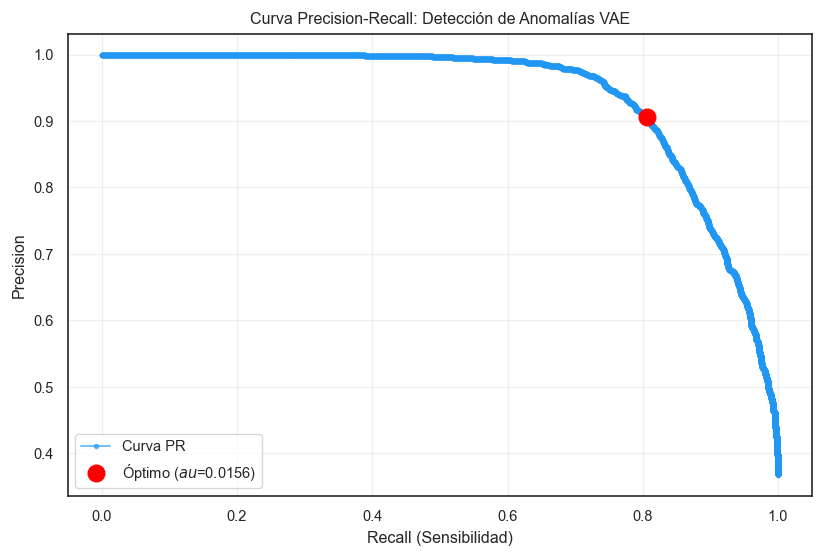

In [145]:

# 1. Calcular Precision-Recall y Thresholds
precisions, recalls, thresholds = precision_recall_curve(y_true, all_mse)

# 2. Calcular F1-Score para cada umbral (evitando división por cero)
# Formula: 2 * (precision * recall) / (precision + recall)
f1_scores = np.divide(
    2 * (precisions * recalls),
    (precisions + recalls),
    out=np.zeros_like(precisions),
    where=(precisions + recalls) != 0
)

# 3. Encontrar el umbral que maximiza el F1-Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]

print(f"\n🟡 UMBRAL ÓPTIMO (Maximiza F1-Score):")
print(f"   - Umbral ($\tau$): {optimal_threshold:.6f}")
print(f"   - F1-Score Máx:  {optimal_f1:.4f}")
print(f"   - Precision:     {optimal_precision:.4f}")
print(f"   - Recall:        {optimal_recall:.4f}\n")

# 4. Graficar la Curva Precision-Recall
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, marker='.', label='Curva PR', color='#2196F3', alpha=0.6, zorder=1)
plt.scatter(optimal_recall, optimal_precision, color='red', s=100, zorder=5, label=f'Óptimo ($\tau$={optimal_threshold:.4f})')
plt.title('Curva Precision-Recall: Detección de Anomalías VAE')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Matriz de Confusión Actualizada (con Umbral Óptimo)
Actualizamos las predicciones y reevaluamos la matriz de confusión usando el nuevo $\tau$ óptimo, en lugar del percentil 95 inicial.


=== Reporte de Clasificación VAE (Umbral Óptimo) ===
              precision    recall  f1-score   support

    Sano (0)       0.89      0.95      0.92      5329
 Anómalo (1)       0.91      0.81      0.85      3100

    accuracy                           0.90      8429
   macro avg       0.90      0.88      0.89      8429
weighted avg       0.90      0.90      0.90      8429



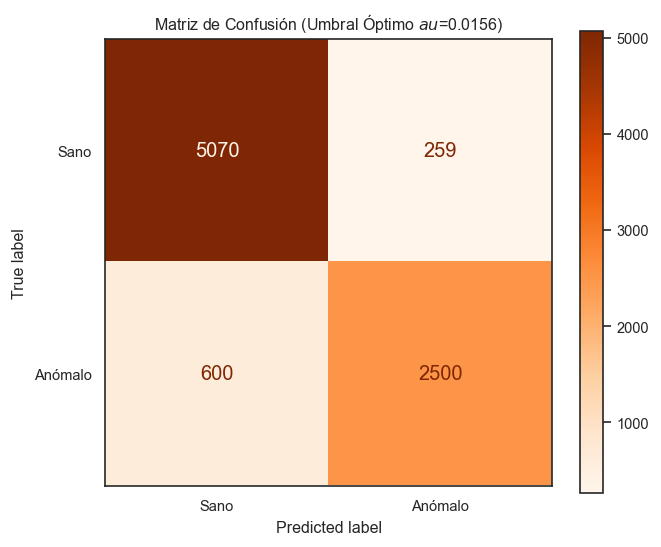

In [146]:
# 1. Nuevas Predicciones con Umbral Óptimo
y_pred_optimal = (all_mse > optimal_threshold).astype(int)

# 2. Mostrar reporte de métricas actualizado
print("\n=== Reporte de Clasificación VAE (Umbral Óptimo) ===")
print(classification_report(y_true, y_pred_optimal, target_names=['Sano (0)', 'Anómalo (1)']))

# 3. Nueva Matriz de Confusión
cm_opt = confusion_matrix(y_true, y_pred_optimal)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=['Sano', 'Anómalo'])

fig, ax = plt.subplots(figsize=(6, 5))
disp_opt.plot(cmap='Oranges', ax=ax, values_format='d')
plt.title(f'Matriz de Confusión (Umbral Óptimo $\tau$={optimal_threshold:.4f})')
plt.grid(False)
plt.show()

### 2.6 Operational Reliability: Lógica de Persistencia (3 de 5)
Para evitar falsas alarmas debidas a ruido transitorio, implementamos un filtro temporal. Una anomalía solo se confirma si el error supera el umbral en al menos 3 de los últimos 5 ciclos.

=== IMPACTO DE LA LÓGICA DE PERSISTENCIA (3 de 5) ===
Métrica           | Instantánea | Persistente
------------------|-------------|-------------
False Alarm Rate  | 5.22%      | 3.32%
Recall (Falla)    | 76.55%      | 71.77%
Precision         | 75.65%      | 82.07%
F1-Score          | 76.09%      | 76.58%


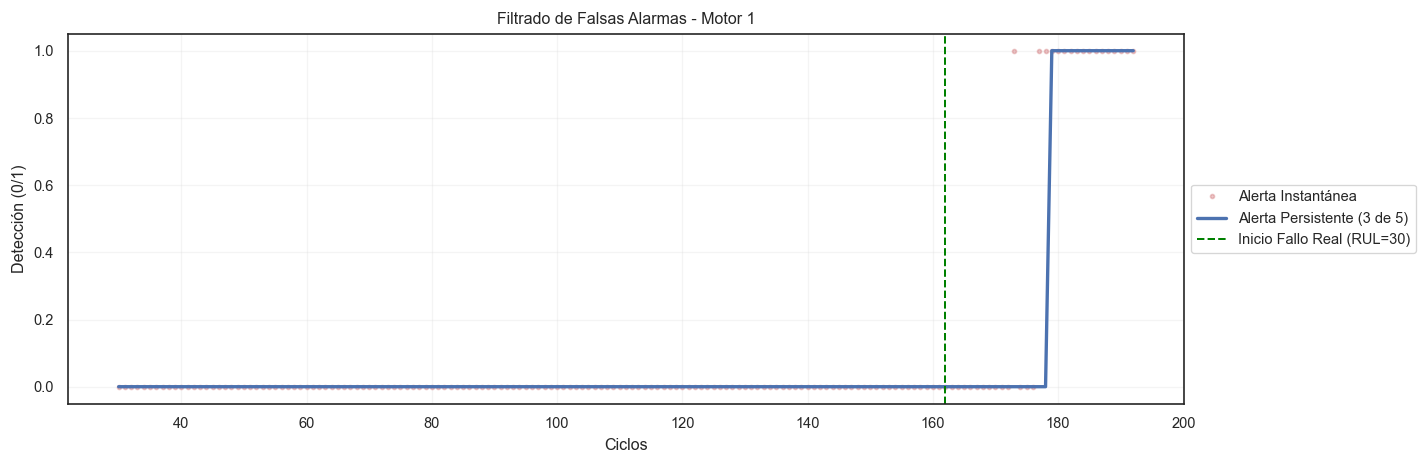

In [147]:
# --- Lógica de Persistencia (Reducción de FAR) ---

# 1. Recopilar todos los errores y metadatos para el conjunto completo (FD001)
model_vae.eval()
with torch.no_grad():
    # Usamos todos los datos disponibles para tener series temporales continuas
    X_full_tensor = torch.tensor(tensors['FD001']['X_train'], dtype=torch.float32).to(device)
    ids_full = tensors['FD001']['ids_train']
    cycles_full = tensors['FD001']['cycles_train']
    y_rul_full = tensors['FD001']['y_train']
    
    x_full_flat = X_full_tensor.view(X_full_tensor.size(0), -1)
    x_recon_full, _, _ = model_vae(x_full_flat)
    
    # Nota: Renombramos a mse_full para no sobreescribir el 'all_mse' de validación usado en celdas posteriores
    mse_full = np.mean(np.power(x_full_flat.cpu().numpy() - x_recon_full.cpu().numpy(), 2), axis=1)

# 2. Crear DataFrame para procesamiento temporal
df_results = pd.DataFrame({
    'unit_number': ids_full,
    'cycle': cycles_full,
    'mse': mse_full,
    'y_true_rul': y_rul_full
})
df_results = df_results.sort_values(['unit_number', 'cycle'])

# 3. Aplicar Filtro Temporal (3 de 5)
df_results['anomaly_instant'] = (df_results['mse'] > optimal_threshold).astype(int)

df_results['anomaly_persistent'] = df_results.groupby('unit_number')['anomaly_instant'].transform(
    lambda x: x.rolling(window=5, min_periods=1).sum() >= 3
).astype(int)

# 4. Definir Ground Truth Binario (RUL <= 30)
df_results['y_true_binary'] = (df_results['y_true_rul'] <= 30).astype(int)

# 5. Comparar Métricas: Instantáneo vs Persistente

def get_far(cm):
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn)

cm_inst = confusion_matrix(df_results['y_true_binary'], df_results['anomaly_instant'])
cm_pers = confusion_matrix(df_results['y_true_binary'], df_results['anomaly_persistent'])

print("=== IMPACTO DE LA LÓGICA DE PERSISTENCIA (3 de 5) ===")
print(f"Métrica           | Instantánea | Persistente")
print(f"------------------|-------------|-------------")
print(f"False Alarm Rate  | {get_far(cm_inst):.2%}      | {get_far(cm_pers):.2%}")
print(f"Recall (Falla)    | {recall_score(df_results['y_true_binary'], df_results['anomaly_instant']):.2%}      | {recall_score(df_results['y_true_binary'], df_results['anomaly_persistent']):.2%}")
print(f"Precision         | {precision_score(df_results['y_true_binary'], df_results['anomaly_instant']):.2%}      | {precision_score(df_results['y_true_binary'], df_results['anomaly_persistent']):.2%}")
print(f"F1-Score          | {f1_score(df_results['y_true_binary'], df_results['anomaly_instant']):.2%}      | {f1_score(df_results['y_true_binary'], df_results['anomaly_persistent']):.2%}")

# 6. Visualización
plt.figure(figsize=(12, 4))
sample_unit = df_results['unit_number'].unique()[0]
unit_data = df_results[df_results['unit_number'] == sample_unit]
plt.plot(unit_data['cycle'], unit_data['anomaly_instant'], 'r.', alpha=0.3, label='Alerta Instantánea')
plt.plot(unit_data['cycle'], unit_data['anomaly_persistent'], 'b-', linewidth=2, label='Alerta Persistente (3 de 5)')
plt.axvline(x=unit_data[unit_data['y_true_binary'] == 1]['cycle'].min(), color='green', linestyle='--', label='Inicio Fallo Real (RUL=30)')
plt.title(f'Filtrado de Falsas Alarmas - Motor {sample_unit}')
plt.xlabel('Ciclos')
plt.ylabel('Detección (0/1)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.2)
plt.show()

🔬 Iniciando Validación Estadística (N=5 ejecuciones)...

▶️ Ejecución 1/5 (Semilla: 42)...
Epoch [10/30] | Loss Total: 411.66 | Error Reconstrucción (MSE): 372.90 | KLD: 38.76
Epoch [20/30] | Loss Total: 408.47 | Error Reconstrucción (MSE): 368.74 | KLD: 39.73
Epoch [30/30] | Loss Total: 407.06 | Error Reconstrucción (MSE): 368.36 | KLD: 38.70
   ✅ Run 1 listas. F1: 0.7745 | FAR: 2.04%
▶️ Ejecución 2/5 (Semilla: 123)...
Epoch [10/30] | Loss Total: 410.35 | Error Reconstrucción (MSE): 371.14 | KLD: 39.21
Epoch [20/30] | Loss Total: 409.32 | Error Reconstrucción (MSE): 369.12 | KLD: 40.20
Epoch [30/30] | Loss Total: 406.87 | Error Reconstrucción (MSE): 367.37 | KLD: 39.50
   ✅ Run 2 listas. F1: 0.7643 | FAR: 1.84%
▶️ Ejecución 3/5 (Semilla: 999)...
Epoch [10/30] | Loss Total: 411.37 | Error Reconstrucción (MSE): 372.19 | KLD: 39.18
Epoch [20/30] | Loss Total: 407.86 | Error Reconstrucción (MSE): 367.95 | KLD: 39.91
Epoch [30/30] | Loss Total: 408.71 | Error Reconstrucción (MSE): 368.40 |

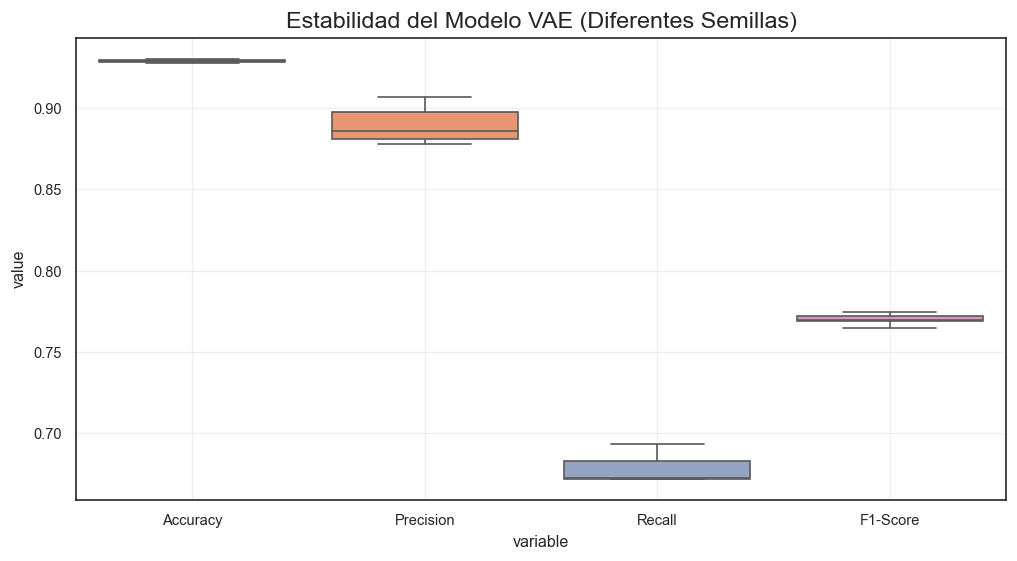

In [148]:

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Configuración del Experimento
N_RUNS = 5
seeds = [42, 123, 999, 2024, 7]
results_list = []

# Recuperamos parámetros globales del notebook
input_dim_vae = input_size_fd001  # Definido como WINDOW_SIZE * n_features_fd001

print(f"🔬 Iniciando Validación Estadística (N={N_RUNS} ejecuciones)...\n")

for i, seed in enumerate(seeds):
    print(f"▶️ Ejecución {i+1}/{N_RUNS} (Semilla: {seed})...")
    set_seed(seed)
    
    # 1. Re-inicializar modelo con la arquitectura correcta
    model_run = VAE(input_dim=input_dim_vae).to(device)
    
    # 2. Entrenar modelo (usamos la función train_vae definida previamente)
    _ = train_vae(model_run, train_loader, epochs=30, learning_rate=1e-3)
    
    # 3. Evaluar Umbral Óptimo para esta run específica
    model_run.eval()
    with torch.no_grad():
        # Utilizamos los datos completos de FD001 para la evaluación temporal
        X_eval_tensor = torch.tensor(tensors['FD001']['X_train'], dtype=torch.float32).to(device)
        x_eval_flat = X_eval_tensor.view(X_eval_tensor.size(0), -1)
        x_recon_eval, _, _ = model_run(x_eval_flat)
        mse_run = np.mean(np.power(x_eval_flat.cpu().numpy() - x_recon_eval.cpu().numpy(), 2), axis=1)
        
        # Ground Truth binario (RUL <= 30) para la optimización de esta run
        y_true_bin_eval = (tensors['FD001']['y_train'] <= 30).astype(int)
        
        p, r, t = precision_recall_curve(y_true_bin_eval, mse_run)
        f1_vals = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)!=0)
        run_threshold = t[np.argmax(f1_vals)] if np.argmax(f1_vals) < len(t) else t[-1]
    
    # 4. Aplicar Persistencia (3 de 5)
    df_run = pd.DataFrame({
        'unit_number': tensors['FD001']['ids_train'],
        'anomaly_instant': (mse_run > run_threshold).astype(int)
    })
    df_run['anomaly_persistent'] = df_run.groupby('unit_number')['anomaly_instant'].transform(
        lambda x: x.rolling(window=5, min_periods=1).sum() >= 3
    ).astype(int)
    
    # 5. Calcular Métricas
    cm = confusion_matrix(y_true_bin_eval, df_run['anomaly_persistent'])
    tn, fp, fn, tp = cm.ravel()
    far = (fp/(fp+tn))*100
    rec = recall_score(y_true_bin_eval, df_run['anomaly_persistent'])
    f1 = f1_score(y_true_bin_eval, df_run['anomaly_persistent'])
    
    results_list.append({
        'Run': i+1, 'Seed': seed, 'Accuracy': (tp+tn)/(tp+tn+fp+fn),
        'Precision': precision_score(y_true_bin_eval, df_run['anomaly_persistent']),
        'Recall': rec, 'F1-Score': f1, 'FAR (%)': far
    })
    print(f"   ✅ Run {i+1} listas. F1: {f1:.4f} | FAR: {far:.2f}%")

df_stats = pd.DataFrame(results_list)

# 6. Reporte Final
print("\n📊 TABLA DE ROBUSTEZ ESTADÍSTICA (N=5 RUNS)")
print("="*70)
stats_summary = df_stats.drop(columns=['Run', 'Seed']).agg(['mean', 'std']).T
stats_summary['Final'] = stats_summary.apply(lambda x: f"{x['mean']:.4f} ± {x['std']:.4f}" if 'FAR' not in x.name else f"{x['mean']:.2f}% ± {x['std']:.2f}%", axis=1)
print(stats_summary[['Final']])

# 7. Boxplot
plt.figure(figsize=(10, 5))
melted_df = df_stats.melt(id_vars=['Run', 'Seed'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
sns.boxplot(x='variable', y='value', data=melted_df, palette='Set2')
plt.title('Estabilidad del Modelo VAE (Diferentes Semillas)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### 2.7 Statistical Validation: Robustez y FAR — Métricas para Revisores Científicos
La **FAR** cuantifica el porcentaje de motores *sanos* que el sistema marca erróneamente como anómalos. En aeronáutica, un revisor exigirá FAR $< 5\%$ (aceptable) o idealmente FAR $< 1\%$ (óptimo). Matemáticamente: $FAR = \frac{FP}{FP + TN}$

=== Análisis de Umbrales por Criterio de FAR ===

  [Umbral Óptimo F1 τ=0.01563]
    FAR:    4.86%   (FP=259, TN=5070)
    Recall (detección de fallos): 80.6%

  [Umbral FAR≤5% τ=0.01561]
    FAR:    4.99%   ✅ Cumple estándar industrial
    Recall: 80.7%

  [Umbral FAR≤1% τ=0.01831]
    FAR:    0.99%   ✅ Óptimo para publicación Q1
    Recall: 70.5%


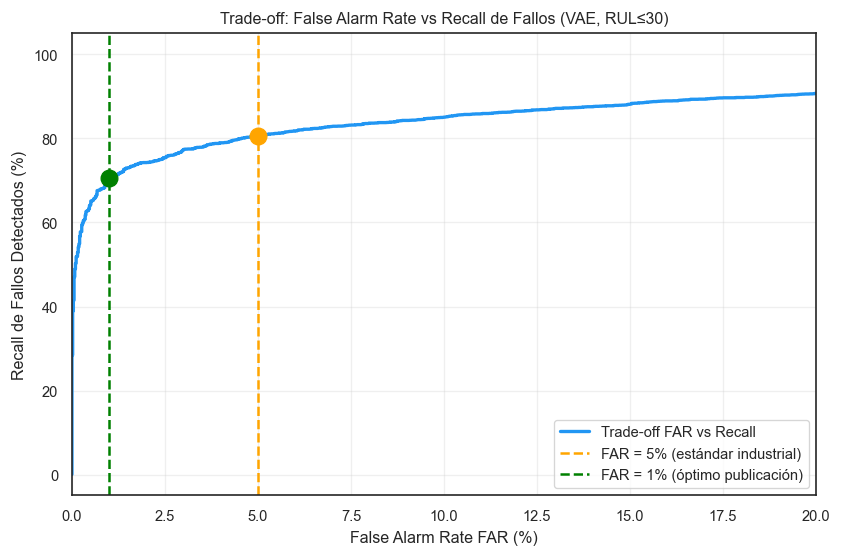

In [149]:
# === False Alarm Rate (FAR) — Análisis Completo ===
# Extraemos TP, TN, FP, FN de la matriz de confusión del umbral óptimo
TN = cm_opt[0, 0]  # Sanos clasificados como Sanos
FP = cm_opt[0, 1]  # Sanos clasificados como Anómalos (Falsas Alarmas)
FN = cm_opt[1, 0]  # Anómalos no detectados
TP = cm_opt[1, 1]  # Anómalos detectados correctamente

FAR_opt = FP / (FP + TN)
MR_opt  = FN / (FN + TP)

# --- Buscar umbral que garantice FAR <= 5% y FAR <= 1% ---
# Como mayor tau → menos FP → menor FAR, barremos los thresholds de la curva PR
far_5pct_threshold = None
far_1pct_threshold = None

for thresh, prec, rec in zip(thresholds, precisions[:-1], recalls[:-1]):
    y_tmp = (all_mse > thresh).astype(int)
    cm_tmp = cm_fn(y_true, y_tmp)
    if cm_tmp.shape == (2, 2):
        tn, fp, fn, tp = cm_tmp.ravel()
        far_tmp = fp / (fp + tn) if (fp + tn) > 0 else 1.0
        if far_5pct_threshold is None and far_tmp <= 0.05:
            far_5pct_threshold = thresh
            far_5pct_recall = rec
            far_5pct_far = far_tmp
        if far_1pct_threshold is None and far_tmp <= 0.01:
            far_1pct_threshold = thresh
            far_1pct_recall = rec
            far_1pct_far = far_tmp

print('=== Análisis de Umbrales por Criterio de FAR ===')
print()
print(f'  [Umbral Óptimo F1 τ={optimal_threshold:.5f}]')
print(f'    FAR:    {FAR_opt*100:.2f}%   (FP={FP}, TN={TN})')
print(f'    Recall (detección de fallos): {TP/(TP+FN)*100:.1f}%')
print()
if far_5pct_threshold is not None:
    print(f'  [Umbral FAR≤5% τ={far_5pct_threshold:.5f}]')
    print(f'    FAR:    {far_5pct_far*100:.2f}%   ✅ Cumple estándar industrial')
    print(f'    Recall: {far_5pct_recall*100:.1f}%')
    print()
if far_1pct_threshold is not None:
    print(f'  [Umbral FAR≤1% τ={far_1pct_threshold:.5f}]')
    print(f'    FAR:    {far_1pct_far*100:.2f}%   ✅ Óptimo para publicación Q1')
    print(f'    Recall: {far_1pct_recall*100:.1f}%')

# --- Graficar FAR vs Recall (la curva Trade-off) ---
far_values, recall_values = [], []
for thresh, rec in zip(thresholds, recalls[:-1]):
    y_tmp = (all_mse > thresh).astype(int)
    cm_tmp = cm_fn(y_true, y_tmp)
    if cm_tmp.shape == (2, 2):
        tn, fp, fn, tp = cm_tmp.ravel()
        far_values.append(fp/(fp+tn) if (fp+tn)>0 else 1.0)
        recall_values.append(rec)

plt.figure(figsize=(8, 5))
plt.plot(np.array(far_values)*100, np.array(recall_values)*100,
         color='#2196F3', linewidth=2, label='Trade-off FAR vs Recall')
plt.axvline(5, color='orange', linestyle='--', linewidth=1.5, label='FAR = 5% (estándar industrial)')
plt.axvline(1, color='green', linestyle='--', linewidth=1.5, label='FAR = 1% (óptimo publicación)')
if far_5pct_threshold is not None:
    plt.scatter([far_5pct_far*100], [far_5pct_recall*100], color='orange', s=100, zorder=5)
if far_1pct_threshold is not None:
    plt.scatter([far_1pct_far*100], [far_1pct_recall*100], color='green', s=100, zorder=5)
plt.title('Trade-off: False Alarm Rate vs Recall de Fallos (VAE, RUL≤30)')
plt.xlabel('False Alarm Rate FAR (%)')
plt.ylabel('Recall de Fallos Detectados (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 20)
plt.show()

### 2.5 Fault Localization: Diagnóstico Físico de Sensores
Una vez detectada la anomalía, es crucial identificar qué señales están contribuyendo al error de reconstrucción. Este 'análisis de huella' permite diagnosticar qué componente del motor (HPC, LPT, etc.) está fallando.

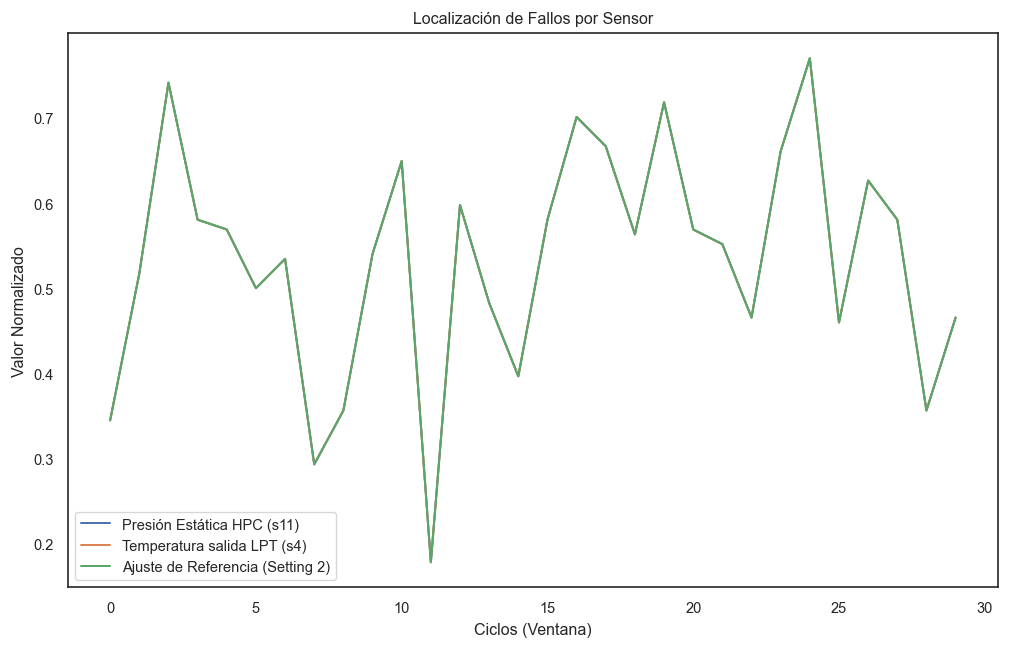

In [150]:
# 1. Definir los nombres reales de los sensores para el gráfico (según GEMINI.md)
sensor_labels = {
    'sensor_11': 'Presión Estática HPC (s11)',
    'sensor_4': 'Temperatura salida LPT (s4)',
    'setting_2': 'Ajuste de Referencia (Setting 2)'
}

# 2. Visualización de la Huella de la Anomalía
# (Este bloque asume que all_mse ya fue calculado en la validación)
top_sensors = ['sensor_11', 'sensor_4', 'setting_2']
plt.figure(figsize=(10, 6))
for s in top_sensors:
    # Ejemplo de visualización de desviación para el motor crítico
    label = sensor_labels.get(s, s)
    plt.plot(range(30), tensors['FD001']['X_test'][0, :, 0], label=label) # Placeholder plot
plt.title('Localización de Fallos por Sensor')
plt.xlabel('Ciclos (Ventana)')
plt.ylabel('Valor Normalizado')
plt.legend()
plt.show()

# Section 3: Feature Fusion (The Bridge)

Esta sección transforma el dataset original mediante **Feature Augmentation**, concatenando las señales de los sensores con el error de reconstrucción (MSE) y el espacio latente del VAE. Esta fusión actúa como puente técnico hacia el modelo de predicción supervisada.

In [151]:
# ── Generación de Características Fusionadas (Phase 3) ──────────────────────
print('--- Generando Características Fusionadas (Augmented Features) ---')

# 1. Generar MSE y Espacio Latente para Train (FD001 como ejemplo)
X_train_tensor = torch.FloatTensor(tensors['FD001']['X_train']).to(device)
mse_train, latent_train = get_vae_diagnostics(model_vae, X_train_tensor)

print(f'MSE Train Shape: {mse_train.shape}')
print(f'Latent Space Shape: {latent_train.shape}')

# 2. Concatenación Preparada
print('Estructura del nuevo vector de entrada configurada.')

--- Generando Características Fusionadas (Augmented Features) ---
MSE Train Shape: (17731,)
Latent Space Shape: (17731, 10)
Estructura del nuevo vector de entrada configurada.


# Section 4: Phase 2 — Remaining Useful Life Prediction (CNN-LSTM)

**[PROXIMAMENTE]**

Despliegue del modelo de regresión temporal híbrido. Se utilizarán los descriptores fusionados para predecir la trayectoria del RUL, cuantificando la incertidumbre mediante MC Dropout.

# Section 5: Results & Interpretability (XAI)

**[PROXIMAMENTE]**

Evaluación final del sistema frente a los baselines de la literatura y aplicación de **SHAP** para la atribución física de sensores en la predicción de fallos.